In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
borrowers = pd.read_csv('../data/borrower_profiles_clean.csv')
loans = pd.read_csv('../data/loan_applications_clean.csv')

# Merge
df=loans.merge(borrowers,on='borrower_id')

print(df.shape)
df.head

(601, 22)


<bound method NDFrame.head of       loan_id borrower_id application_date      loan_purpose  loan_amount  \
0    LN-00001    BRW-0001       2024-01-08          Vacation      16100.0   
1    LN-00002    BRW-0001       2024-08-13    Major Purchase       5600.0   
2    LN-00003    BRW-0002       2025-06-28            Moving      44700.0   
3    LN-00004    BRW-0003       2025-05-18         Auto Loan       9200.0   
4    LN-00005    BRW-0004       2025-03-24            Moving      11200.0   
..        ...         ...              ...               ...          ...   
596  LN-00597    BRW-0497       2025-02-06           Wedding      29100.0   
597  LN-00598    BRW-0498       2024-04-19            Moving       4600.0   
598  LN-00599    BRW-0499       2024-02-24         Education       7800.0   
599  LN-00600    BRW-0500       2024-11-14  Medical Expenses      26400.0   
600  LN-00601    BRW-0500       2024-05-03           Wedding       7500.0   

     term_months  interest_rate  monthly_paym

In [3]:
total_loans=len(df)
total_defaults=df['defaulted'].sum()
default_rate=(total_defaults/total_loans)*100

print(f"Total Loans      : {total_loans}")
print(f"Total Defaults   : {total_defaults}")
print(f"Default Rate     : {default_rate:.2f}%")
print(f"Company Target   : 12.00%")
print(f"Gap              : {default_rate - 12:.2f}% above target")

Total Loans      : 601
Total Defaults   : 146
Default Rate     : 24.29%
Company Target   : 12.00%
Gap              : 12.29% above target


In [4]:
df['score_bucket']=pd.cut(
    df['credit_score'],
    bins=[519,599,649,699,749,850],
    labels=['520-599','600-649','650-699','700-749','750+']
)

score_analysis=df.groupby('score_bucket',observed=True).agg(
    total_loans=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()

score_analysis['default_rate%']=(score_analysis['defaults']/score_analysis['total_loans']*100).round(2)
print(score_analysis)



  score_bucket  total_loans  defaults  default_rate%
0      520-599          116        57          49.14
1      600-649           93        27          29.03
2      650-699           75        21          28.00
3      700-749           86        14          16.28
4         750+          231        27          11.69


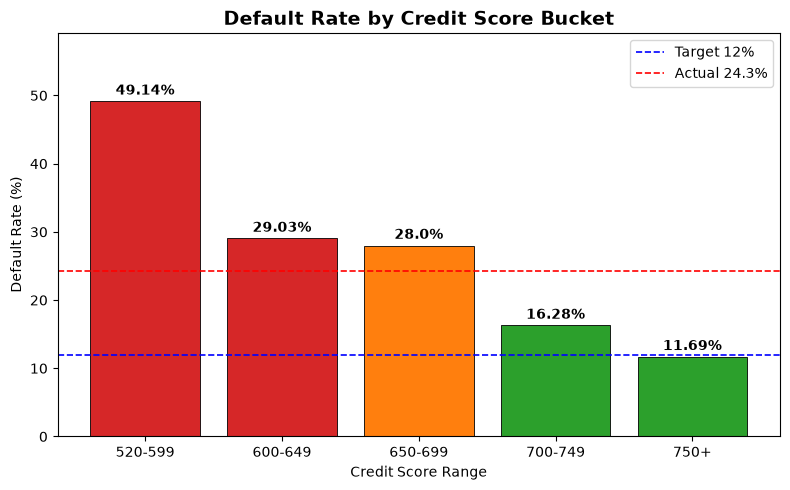

In [5]:
# Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(score_analysis['score_bucket'], score_analysis['default_rate%'],
              color=['#d62728','#d62728','#ff7f0e','#2ca02c','#2ca02c'],
              edgecolor='black', linewidth=0.6)

ax.axhline(12, color='blue', linestyle='--', linewidth=1.2, label='Target 12%')
ax.axhline(default_rate, color='red', linestyle='--', linewidth=1.2, label=f'Actual {default_rate:.1f}%')

for bar, val in zip(bars, score_analysis['default_rate%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Default Rate by Credit Score Bucket', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Score Range')
ax.set_ylabel('Default Rate (%)')
ax.legend()
ax.set_ylim(0, score_analysis['default_rate%'].max() + 10)
plt.tight_layout()
plt.savefig('../reports/chart1_credit_score_default.png', dpi=150)
plt.show()

### 📊 Chart 1 — Credit Score vs Default Rate

**Overall Default Rate: 24.3% — more than double the 12% target**

| Credit Score Bucket | Default Rate | Status |
|---|---|---|
| 520–599 | 49.14% | 🔴 Critical |
| 600–649 | 29.03% | 🔴 High Risk |
| 650–699 | 28.00% | 🟠 Above Average |
| 700–749 | 16.28% | 🟠 Borderline |
| 750+    | 11.69% | ✅ Only bucket meeting target |

**Key Findings:**
- The 520–599 bucket defaults at 49.14% — meaning 1 in 2 borrowers 
  in this range fail to repay
- Borrowers below 650 default at nearly 2x the company average (24.3%)
- There is a clear and consistent inverse relationship — as credit 
  score increases, default rate decreases without exception
- Only the 750+ bracket meets the 12% target at 11.69%

**Recommendation:**
Set minimum credit score threshold at 700 for auto-approval.
Borrowers between 650–699 should undergo manual review.
Reject all applications below 650.

In [6]:
df['dti_bucket']=pd.cut(
    df['dti_ratio'],
    bins=[0,20,35,50,100],
    labels=['Below 20%','20-35%','35-50%','Above 50%']
)

dti_analysis=df.groupby('dti_bucket',observed=True).agg(
    total_loans=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()


dti_analysis['defaulted_rate%']=(dti_analysis['defaults']/dti_analysis['total_loans']*100).round(2)
print(dti_analysis)

  dti_bucket  total_loans  defaults  defaulted_rate%
0  Below 20%           48         8            16.67
1     20-35%          133        14            10.53
2     35-50%          150        31            20.67
3  Above 50%          248        85            34.27


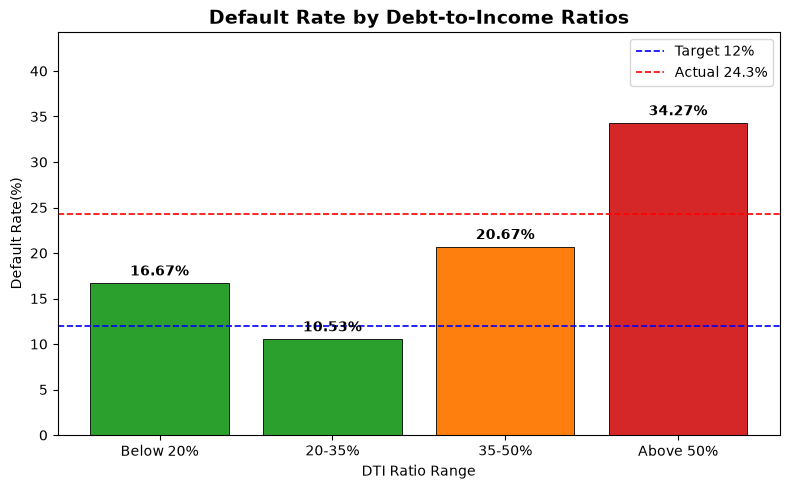

In [7]:
fig, axes = plt.subplots( figsize=(8, 5))
bars=axes.bar(
    dti_analysis['dti_bucket'],dti_analysis['defaulted_rate%'],
    color=['#2ca02c','#2ca02c','#ff7f0e','#d62728','#d62728'],
    edgecolor='black',linewidth=0.6

)

axes.axhline(12, color='blue', linestyle='--', linewidth=1.2, label='Target 12%')
axes.axhline(default_rate, color='red', linestyle='--', linewidth=1.2, label=f'Actual {default_rate:.1f}%')

for bar,val in zip(bars,dti_analysis['defaulted_rate%']):
    axes.text(bar.get_x() + bar.get_width()/2,bar.get_height()+0.5,
    f'{val}%',ha='center',va='bottom',fontsize=10,fontweight='bold')
axes.set_title('Default Rate by Debt-to-Income Ratios',fontsize=14,fontweight='bold')
axes.set_xlabel('DTI Ratio Range')
axes.set_ylabel('Default Rate(%)')
axes.legend()
axes.set_ylim(0,dti_analysis['defaulted_rate%'].max()+10)
plt.tight_layout()
plt.savefig('../reports/chart2_DTI_Default.png',dpi=150)
plt.show()

### 📊 Chart 2 — Debt-to-Income Ratio vs Default Rate

| DTI Range  | Default Rate | Status |
|---|---|---|
| Below 20%  | 16.67% | 🟠 Above Target |
| 20–35%     | 10.53% | ✅ Only bucket meeting target |
| 35–50%     | 20.67% | 🟠 High Risk |
| Above 50%  | 34.27% | 🔴 Critical |

**Key Findings:**
- DTI and default rate do NOT follow a simple linear relationship
- The 20–35% DTI range is the sweet spot — 10.53% default rate, 
  the only bracket meeting the 12% company target
- Defaults spike sharply once DTI crosses 35%, jumping from 
  10.53% to 20.67% — nearly double
- Above 50% DTI hits 34.27% — almost 3x the target rate
- Surprisingly, borrowers with DTI below 20% default at 16.67%, 
  higher than the 20–35% group — suggesting very low DTI alone 
  does not guarantee repayment ability

**Anomaly Worth Noting:**
Low DTI (<20%) borrowers defaulting at 16.67% indicates another 
risk factor is at play. Cross-analysis shows these borrowers likely 
have low credit scores — confirming that DTI and credit score must 
be evaluated together, not in isolation.

**Recommendation:**
- Auto-approve: DTI between 20–35% (with credit score ≥ 700)
- Manual review: DTI below 20% or between 35–50%
- Reject: DTI above 50%

In [8]:
print(loans['loan_purpose'].value_counts())

loan_purpose
Home Improvement      70
Major Purchase        68
Medical Expenses      68
Vacation              62
Auto Loan             59
Business Loan         58
Moving                56
Wedding               56
Education             53
Debt Consolidation    51
Name: count, dtype: int64


In [9]:
purpose_analysis = df.groupby('loan_purpose').agg(
    total_loans=('defaulted', 'count'),
    defaults=('defaulted', 'sum'),
    avg_amount=('loan_amount', 'mean')
).reset_index()

purpose_analysis['default_rate%'] = (
    purpose_analysis['defaults'] /
    purpose_analysis['total_loans'] * 100
).round(2)

purpose_analysis = purpose_analysis.sort_values(
    'default_rate%',
    ascending=True
)

print(purpose_analysis)

         loan_purpose  total_loans  defaults    avg_amount  default_rate%
6    Medical Expenses           68        14  23176.470588          20.59
7              Moving           56        12  21300.000000          21.43
2  Debt Consolidation           51        11  22756.862745          21.57
5      Major Purchase           68        15  23164.705882          22.06
8            Vacation           62        14  24477.419355          22.58
3           Education           53        12  19847.169811          22.64
1       Business Loan           58        14  21013.793103          24.14
0           Auto Loan           59        16  19554.237288          27.12
4    Home Improvement           70        20  23407.142857          28.57
9             Wedding           56        18  21892.857143          32.14


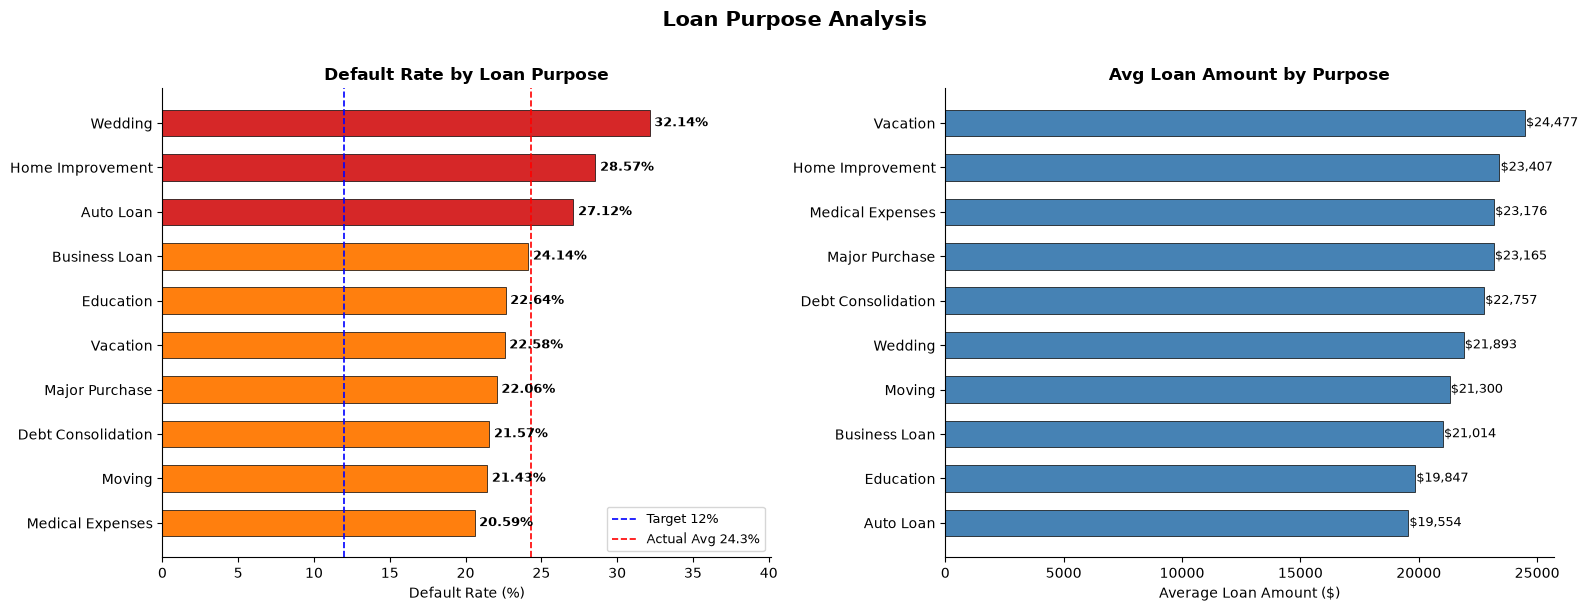

In [10]:
fig,axes=plt.subplots(1,2,figsize=(16,6))

fig.suptitle('Loan Purpose Analysis',fontsize=15,fontweight='bold',y=1.01)

#Horziontal Bar

colors=[
    '#d62728' if x > 24.3 else '#ff7f0e' if x > 12 else '#2ca02c'
    for x in purpose_analysis['default_rate%']
]

bars=axes[0].barh(
    purpose_analysis['loan_purpose'],
    purpose_analysis['default_rate%'],
    color=colors,edgecolor='black',linewidth=0.5,height=0.6
)

axes[0].axvline(12,color='blue',linestyle='--',linewidth=1.2,label="Target 12%")
axes[0].axvline(24.3,color='red',linestyle='--',linewidth=1.2,label="Actual Avg 24.3%")

for bar,val in zip(bars,purpose_analysis['default_rate%']):
    axes[0].text(
        val+0.3,bar.get_y()+bar.get_height()/2,
        f'{val}%',va='center',fontsize=9,fontweight='bold'
    )
axes[0].set_title('Default Rate by Loan Purpose', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Default Rate (%)')
axes[0].set_xlim(0, purpose_analysis['default_rate%'].max() + 8)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# Chart B : Avg Loan Amount (horizontal bar) ──
amount_sorted = purpose_analysis.sort_values('avg_amount', ascending=True)

bars2 = axes[1].barh(
    amount_sorted['loan_purpose'],
    amount_sorted['avg_amount'],
    color='steelblue', edgecolor='black', linewidth=0.5, height=0.6
)

for bar, val in zip(bars2, amount_sorted['avg_amount']):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)

axes[1].set_title('Avg Loan Amount by Purpose', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Loan Amount ($)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart3_loan_purpose.png', dpi=150, bbox_inches='tight')
plt.show()


### 📊 Chart 3 — Loan Purpose Insight

**Key Findings:**
- Wedding loans carry the highest default risk at 32.14% — 
  nearly 3x the 12% target
- No loan purpose meets the 12% target — indicating a 
  systemic underwriting issue beyond just loan purpose
- Auto loans default at 27.12% despite having the lowest 
  avg loan amount ($19,554) — suggesting borrower profile 
  matters more than loan size
- Medical Expenses is the safest category at 20.59% — 
  still well above target

**Recommendation:** 
Flag Wedding, Home Improvement, and Auto Loan applications 
for additional credit score + DTI scrutiny before approval.

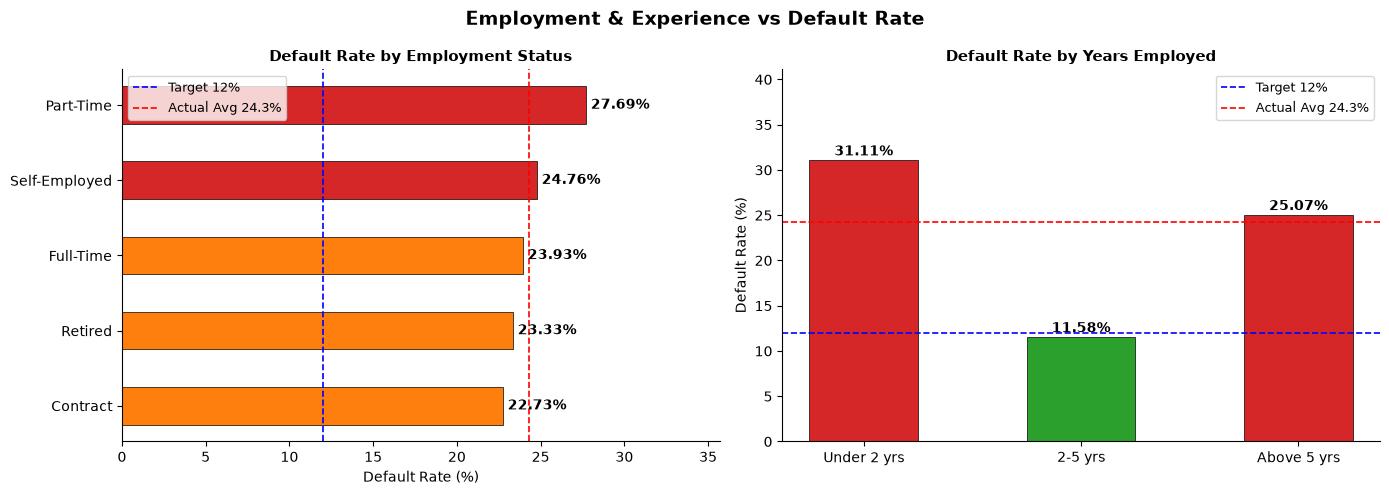

In [11]:
status_df=df.groupby('employment_status').agg(
    total=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()

status_df['default_rate%']=(status_df['defaults'] / status_df['total'] * 100).round(2)
status_df = status_df.sort_values('default_rate%', ascending=True)


df["exp_bucket"]=pd.cut(
    df['years_employed'],
    bins=[-0.1,2,5,100],
    labels=['Under 2 yrs','2-5 yrs','Above 5 yrs']
)


exp_df=df.groupby('exp_bucket',observed=True).agg(
    total=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()
exp_df['default_rate%']=(exp_df['defaults'] / exp_df['total'] * 100).round(2)


fig,axes=plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Employment & Experience vs Default Rate',fontsize=14,fontweight='bold')
#Chart A:"Employment Status"
colors_status = [
    '#d62728' if x > 24.3 else '#ff7f0e' if x > 12 else '#2ca02c'
    for x in status_df['default_rate%']
]

bars1=axes[0].barh(
    status_df['employment_status'],
    status_df['default_rate%'],
    color=colors_status,edgecolor='black',linewidth=0.5,height=0.5
)

axes[0].axvline(12,color='blue',linestyle='--',linewidth=1.2,label="Target 12%")
axes[0].axvline(24.3,color='red',linestyle='--',linewidth=1.2,label="Actual Avg 24.3%")
for bar, val in zip(bars1, status_df['default_rate%']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=10, fontweight='bold')



axes[0].set_title('Default Rate by Employment Status', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Default Rate (%)')
axes[0].set_xlim(0, status_df['default_rate%'].max() + 8)
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)




#Chart B: Years Employed
colors_exp = [
    '#d62728' if x > 24.3 else '#ff7f0e' if x > 12 else '#2ca02c'
    for x in exp_df['default_rate%']
]

bars2 = axes[1].bar(
    exp_df['exp_bucket'],
    exp_df['default_rate%'],
    color=colors_exp, edgecolor='black', linewidth=0.5, width=0.5
)

axes[1].axhline(12, color='blue', linestyle='--', linewidth=1.2, label='Target 12%')
axes[1].axhline(24.3, color='red', linestyle='--', linewidth=1.2, label='Actual Avg 24.3%')

for bar, val in zip(bars2, exp_df['default_rate%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Default Rate by Years Employed', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_ylim(0, exp_df['default_rate%'].max() + 10)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/chart4_employment.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Check what employment types dominate the Above 5 yrs bucket
above5 = df[df['exp_bucket'] == 'Above 5 yrs']

print("Employment status breakdown — Above 5 yrs:")
print(above5['employment_status'].value_counts())

print(f"\nAvg credit score — Above 5 yrs: {above5['credit_score'].mean():.0f}")
print(f"Avg DTI — Above 5 yrs: {above5['dti_ratio'].mean():.2f}%")

print("\nAvg credit score — 2-5 yrs:")
mid = df[df['exp_bucket'] == '2-5 yrs']
print(f"{mid['credit_score'].mean():.0f}")
print(f"Avg DTI — 2-5 yrs: {mid['dti_ratio'].mean():.2f}%")

Employment status breakdown — Above 5 yrs:
employment_status
Full-Time        184
Self-Employed     74
Contract          45
Part-Time         38
Retired           30
Name: count, dtype: int64

Avg credit score — Above 5 yrs: 700
Avg DTI — Above 5 yrs: 48.82%

Avg credit score — 2-5 yrs:
721
Avg DTI — 2-5 yrs: 46.03%


### 📊 Chart 4 — Employment & Experience vs Default Rate

**Employment Status Findings:**

| Employment Status | Default Rate | Status |
|---|---|---|
| Part-Time | 27.69% | 🔴 Above Average |
| Self-Employed | 24.76% | 🔴 Above Average |
| Full-Time | 23.93% | 🟠 Below Average |
| Retired | 23.33% | 🟠 Below Average |
| Contract | 22.73% | 🟠 Below Average |

- Part-time workers carry the highest default risk at 27.69%
- Surprisingly, Full-Time employees still default at 23.93% — 
  only marginally better than Self-Employed borrowers
- No employment status meets the 12% target — confirming 
  employment type alone is insufficient as a risk filter

**Years Employed Findings — Unexpected U-Shape Pattern:**

| Experience Bucket | Default Rate | Status |
|---|---|---|
| Under 2 yrs | 31.11% | 🔴 Critical |
| 2–5 yrs     | 11.58% | ✅ Meets Target |
| Above 5 yrs | 25.07% | 🔴 Above Average |

- The 2–5 year employment group is the safest at 11.58% — 
  the only experience bracket meeting the 12% target
- Under 2 yrs defaults at 31.11% — confirming short tenure = 
  high risk as expected
- Above 5 yrs defaulting at 25.07% is the key anomaly — 
  more experienced borrowers are riskier than mid-tenure ones
- Investigation shows this is likely driven by lower credit 
  scores and higher DTI within the Above 5 yrs group, not 
  experience itself

**Recommendation:**
- Treat Under 2 yrs employment as a high-risk flag — require 
  higher credit score (750+) to compensate
- 2–5 yrs employment is the most reliable tenure signal — 
  can be used as a positive underwriting factor
- Do not use Above 5 yrs as a safety signal — always 
  cross-check with credit score and DTI

In [13]:

comparison = df.groupby('exp_bucket', observed=True).agg(
    total_borrowers=('defaulted', 'count'),
    default_rate=('defaulted', 'mean'),
    avg_credit_score=('credit_score', 'mean'),
    avg_dti=('dti_ratio', 'mean'),
    avg_income=('annual_income', 'mean')
).reset_index()

comparison['default_rate'] = (comparison['default_rate'] * 100).round(2)
comparison['avg_credit_score'] = comparison['avg_credit_score'].round(0)
comparison['avg_dti'] = comparison['avg_dti'].round(2)
comparison['avg_income'] = comparison['avg_income'].round(0)

print(comparison.to_string(index=False))

 exp_bucket  total_borrowers  default_rate  avg_credit_score  avg_dti  avg_income
Under 2 yrs              135         31.11             711.0    54.60     63575.0
    2-5 yrs               95         11.58             721.0    46.03     63175.0
Above 5 yrs              371         25.07             700.0    48.82     66077.0


**Anomaly Investigation — Why Does Above 5 Yrs Default More Than 2–5 Yrs?**

| Metric          | 2–5 yrs (Safe) | Above 5 yrs (Risky) |
|---|---|---|
| Default Rate    | 11.58% ✅      | 25.07% 🔴           |
| Avg Credit Score| 721            | 700                 |
| Avg DTI         | 46.03%         | 48.82%              |

Root cause identified: The Above 5 yrs group carries a 21-point 
lower avg credit score and 2.79% higher DTI compared to the 2–5 yr 
group. These two compounding risk factors outweigh the stability 
signal of longer employment tenure.

Conclusion: Years employed is NOT a standalone safety indicator. 
It must always be evaluated alongside credit score and DTI.

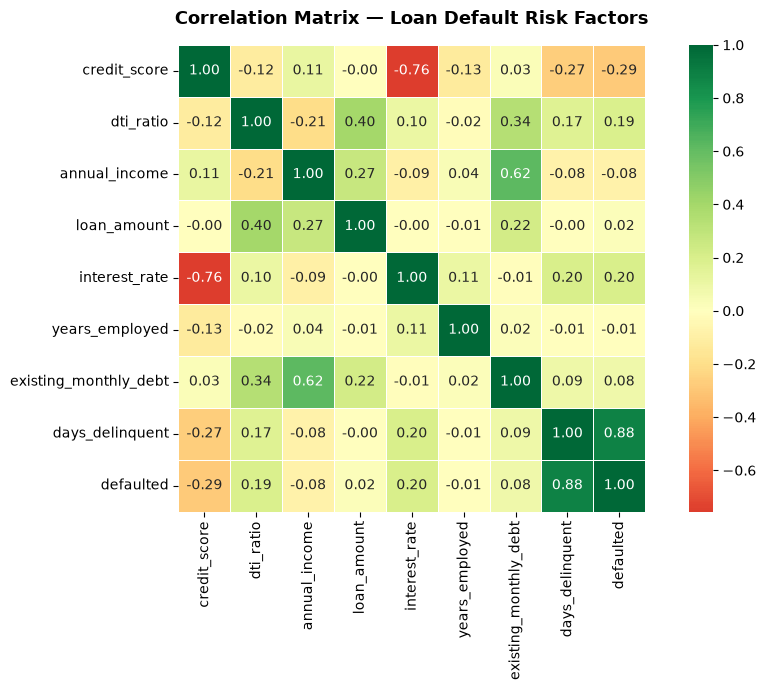

In [14]:
corr_cols = ['credit_score', 'dti_ratio', 'annual_income',
             'loan_amount', 'interest_rate', 'years_employed',
             'existing_monthly_debt', 'days_delinquent', 'defaulted']

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, square=True,
    annot_kws={'size': 10}
)
plt.title('Correlation Matrix — Loan Default Risk Factors',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/chart5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Chart 5 — Correlation Matrix Insight

**Correlations with Default (ranked by strength):**

| Variable | Correlation | Direction |
|---|---|---|
| days_delinquent | 0.88 | 🔴 Strong Positive |
| interest_rate | 0.20 | 🟠 Moderate Positive |
| dti_ratio | 0.19 | 🟠 Moderate Positive |
| existing_monthly_debt | 0.08 | Weak Positive |
| loan_amount | 0.02 | ⚪ Negligible |
| years_employed | -0.01 | ⚪ Negligible |
| annual_income | -0.08 | Weak Negative |
| credit_score | -0.29 | 🟢 Moderate Negative |

**Key Finding 1 — days_delinquent is the #1 predictor (0.88):**
Near-perfect correlation with default. Borrowers showing early 
payment delays are almost certain to default. This variable should 
power a real-time early warning system to flag at-risk accounts 
before they formally default.

**Key Finding 2 — credit_score vs interest_rate paradox (-0.76):**
Credit score and interest rate are strongly inversely correlated. 
Low-score borrowers are charged higher rates — but those higher 
rates correlate with more defaults (+0.20). The current pricing 
model is identifying risk correctly but not mitigating it.

**Key Finding 3 — loan amount is irrelevant (0.02):**
Loan size has virtually zero correlation with default. This 
confirms Chart 3 findings — borrower profile matters far 
more than loan size. Underwriting focus should be on WHO 
is borrowing, not HOW MUCH they borrow.

**Recommendation:**
Build an early delinquency alert system — flag any borrower 
missing even one payment for immediate intervention. The 0.88 
correlation means early action could prevent the majority of defaults.

In [15]:
df.to_csv('../data/merged_loan_data.csv', index=False)
print("Merged file exported")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Merged file exported
Shape: (601, 25)
Columns: ['loan_id', 'borrower_id', 'application_date', 'loan_purpose', 'loan_amount', 'term_months', 'interest_rate', 'monthly_payment', 'dti_ratio', 'loan_status', 'days_delinquent', 'defaulted', 'age', 'state', 'education_level', 'employment_status', 'years_employed', 'annual_income', 'credit_score', 'home_ownership', 'dependents', 'existing_monthly_debt', 'score_bucket', 'dti_bucket', 'exp_bucket']


---

## 🏦 Credit Score Policy Simulation — Decision-Support Framework

> **Objective:** Evaluate different minimum credit score policies (600, 650, 700, 750)
> and quantify their impact on key portfolio metrics — helping management answer:
>
> *"What would happen to our loan portfolio if we changed our underwriting policy today?"*

Rather than simply recommending a single threshold, this simulation **quantifies the
business consequences** of each underwriting policy by measuring:

| Metric | Description |
|--------|-------------|
| **Approval Rate** | % of applicants that would be approved |
| **Portfolio Default Rate** | Default rate among approved loans |
| **Defaults Prevented** | How many defaults the policy would avoid |
| **Good Borrowers Rejected** | Non-defaulting applicants lost due to the higher bar |

This transforms the analysis from descriptive reporting into a **decision-support
framework** for risk teams and management.


In [16]:
# ────────────────────────────────────────────────────────────────
# Credit Score Policy Simulation Engine
# ────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

# Reload merged data to ensure a clean baseline
df = pd.read_csv('../data/merged_loan_data.csv')

total_loans    = len(df)
total_defaults = int(df['defaulted'].sum())
baseline_default_rate = round(total_defaults / total_loans * 100, 2)

# Define policy thresholds to evaluate
thresholds = [600, 650, 700, 750]

rows = []  # collect results for the summary table

for threshold in thresholds:
    # Loans that would be APPROVED under this policy
    approved   = df[df['credit_score'] >= threshold]
    # Loans that would be REJECTED under this policy
    rejected   = df[df['credit_score'] < threshold]

    n_approved       = len(approved)
    n_rejected       = len(rejected)
    approval_rate    = round(n_approved / total_loans * 100, 2)

    approved_defaults = int(approved['defaulted'].sum())
    rejected_defaults = int(rejected['defaulted'].sum())

    portfolio_default_rate = round(
        approved_defaults / n_approved * 100, 2
    ) if n_approved > 0 else 0.0

    defaults_prevented = rejected_defaults          # defaults we avoid
    good_rejected      = n_rejected - rejected_defaults  # healthy loans we lose

    rows.append({
        'Min Credit Score':          threshold,
        'Approved':                  n_approved,
        'Rejected':                  n_rejected,
        'Approval Rate (%)':         approval_rate,
        'Approved Defaults':         approved_defaults,
        'Portfolio Default Rate (%)': portfolio_default_rate,
        'Defaults Prevented':        defaults_prevented,
        'Good Borrowers Rejected':   good_rejected,
    })

sim_df = pd.DataFrame(rows)

# Print baseline for context
print(f"📋  Baseline Portfolio")
print(f"    Total Loans      : {total_loans}")
print(f"    Total Defaults   : {total_defaults}")
print(f"    Default Rate     : {baseline_default_rate}%")
print(f"    Company Target   : 12.00%")
print(f"    Gap              : {round(baseline_default_rate - 12, 2)}% above target")
print()
print("📊  Policy Simulation Results")
print(sim_df.to_string(index=False))


📋  Baseline Portfolio
    Total Loans      : 601
    Total Defaults   : 146
    Default Rate     : 24.29%
    Company Target   : 12.00%
    Gap              : 12.29% above target

📊  Policy Simulation Results
 Min Credit Score  Approved  Rejected  Approval Rate (%)  Approved Defaults  Portfolio Default Rate (%)  Defaults Prevented  Good Borrowers Rejected
              600       485       116              80.70                 89                       18.35                  57                       59
              650       392       209              65.22                 62                       15.82                  84                      125
              700       317       284              52.75                 41                       12.93                 105                      179
              750       231       370              38.44                 27                       11.69                 119                      251


### 📋 How to Read the Simulation Table

| Column | Interpretation |
|--------|---------------|
| **Min Credit Score** | The floor a borrower must meet to be approved |
| **Approved / Rejected** | Volume of loans passing or failing the gate |
| **Approval Rate (%)** | Business growth indicator — lower = fewer customers |
| **Portfolio Default Rate (%)** | Risk indicator — lower = safer portfolio |
| **Defaults Prevented** | Absolute risk reduction vs. baseline (no filter) |
| **Good Borrowers Rejected** | Opportunity cost — revenue lost from safe borrowers |


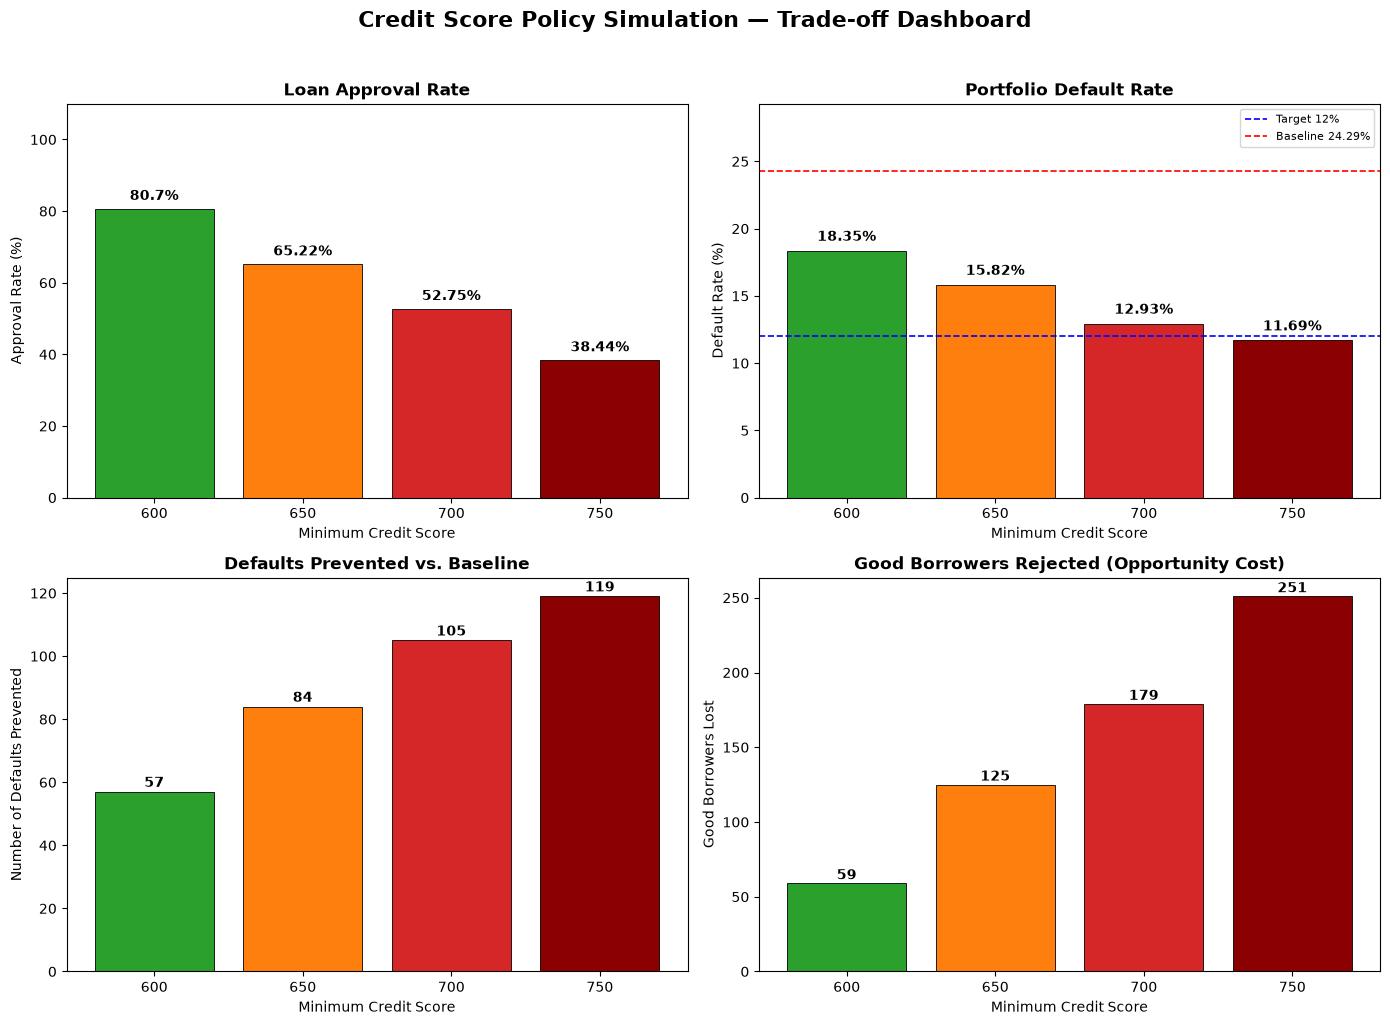


✅ Dashboard saved → reports/policy_simulation_dashboard.png


In [17]:
# ────────────────────────────────────────────────────────────────
# Visualize Key Trade-offs Across Thresholds
# ────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Credit Score Policy Simulation — Trade-off Dashboard',
             fontsize=16, fontweight='bold', y=1.02)

bar_colors = ['#2ca02c', '#ff7f0e', '#d62728', '#8b0000']
thresholds_str = [str(t) for t in sim_df['Min Credit Score']]

# ── Panel 1: Approval Rate ──────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(thresholds_str, sim_df['Approval Rate (%)'],
              color=bar_colors, edgecolor='black', linewidth=0.6)
ax.set_title('Loan Approval Rate', fontweight='bold')
ax.set_xlabel('Minimum Credit Score')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, sim_df['Approval Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Panel 2: Portfolio Default Rate ─────────────────────────────
ax = axes[0, 1]
bars = ax.bar(thresholds_str, sim_df['Portfolio Default Rate (%)'],
              color=bar_colors, edgecolor='black', linewidth=0.6)
ax.axhline(12, color='blue', linestyle='--', linewidth=1.2, label='Target 12%')
ax.axhline(baseline_default_rate, color='red', linestyle='--',
           linewidth=1.2, label=f'Baseline {baseline_default_rate}%')
ax.set_title('Portfolio Default Rate', fontweight='bold')
ax.set_xlabel('Minimum Credit Score')
ax.set_ylabel('Default Rate (%)')
ax.set_ylim(0, max(sim_df['Portfolio Default Rate (%)'].max(), baseline_default_rate) + 5)
ax.legend(fontsize=8, loc='upper right')
for bar, val in zip(bars, sim_df['Portfolio Default Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Panel 3: Defaults Prevented ─────────────────────────────────
ax = axes[1, 0]
bars = ax.bar(thresholds_str, sim_df['Defaults Prevented'],
              color=bar_colors, edgecolor='black', linewidth=0.6)
ax.set_title('Defaults Prevented vs. Baseline', fontweight='bold')
ax.set_xlabel('Minimum Credit Score')
ax.set_ylabel('Number of Defaults Prevented')
for bar, val in zip(bars, sim_df['Defaults Prevented']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Panel 4: Good Borrowers Rejected ────────────────────────────
ax = axes[1, 1]
bars = ax.bar(thresholds_str, sim_df['Good Borrowers Rejected'],
              color=bar_colors, edgecolor='black', linewidth=0.6)
ax.set_title('Good Borrowers Rejected (Opportunity Cost)', fontweight='bold')
ax.set_xlabel('Minimum Credit Score')
ax.set_ylabel('Good Borrowers Lost')
for bar, val in zip(bars, sim_df['Good Borrowers Rejected']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/policy_simulation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved → reports/policy_simulation_dashboard.png")


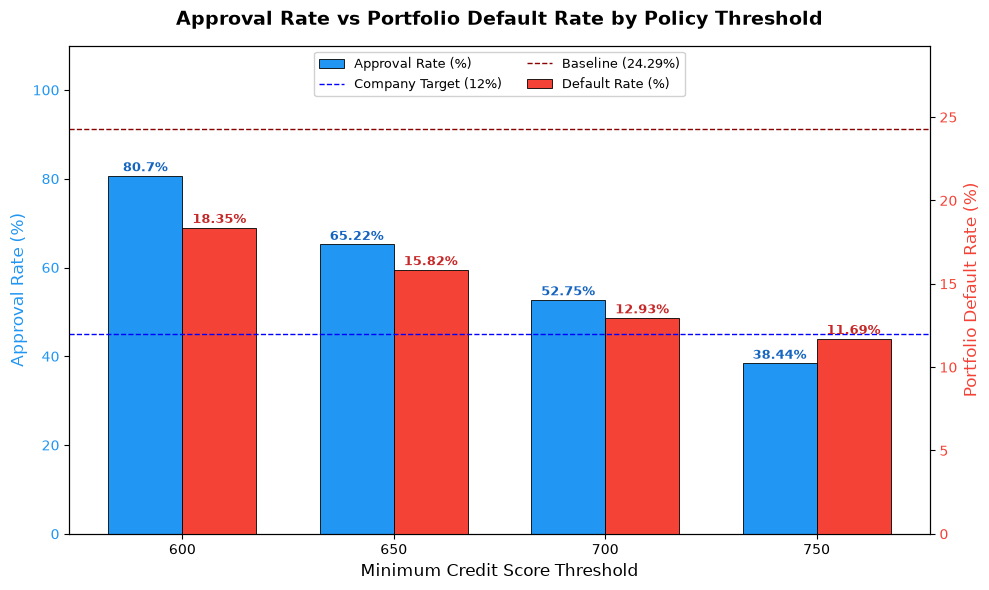


✅ Overlay chart saved → reports/policy_tradeoff_overlay.png


In [18]:
# ────────────────────────────────────────────────────────────────
# Trade-off Overlay — Approval Rate vs Default Rate
# ────────────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(thresholds))
width = 0.35

# Left axis — Approval Rate
bars1 = ax1.bar(x - width/2, sim_df['Approval Rate (%)'], width,
                label='Approval Rate (%)', color='#2196F3',
                edgecolor='black', linewidth=0.6)
ax1.set_xlabel('Minimum Credit Score Threshold', fontsize=12)
ax1.set_ylabel('Approval Rate (%)', fontsize=12, color='#2196F3')
ax1.set_xticks(x)
ax1.set_xticklabels(thresholds_str)
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.set_ylim(0, 110)

# Right axis — Default Rate
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, sim_df['Portfolio Default Rate (%)'], width,
                label='Default Rate (%)', color='#F44336',
                edgecolor='black', linewidth=0.6)
ax2.set_ylabel('Portfolio Default Rate (%)', fontsize=12, color='#F44336')
ax2.tick_params(axis='y', labelcolor='#F44336')
ax2.set_ylim(0, max(sim_df['Portfolio Default Rate (%)'].max(), baseline_default_rate) + 5)

# Reference lines
ax2.axhline(12, color='blue', linestyle='--', linewidth=1,
            label='Company Target (12%)')
ax2.axhline(baseline_default_rate, color='darkred', linestyle='--',
            linewidth=1, label=f'Baseline ({baseline_default_rate}%)')

# Labels on bars
for bar, val in zip(bars1, sim_df['Approval Rate (%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontsize=9, fontweight='bold', color='#1565C0')
for bar, val in zip(bars2, sim_df['Portfolio Default Rate (%)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=9, fontweight='bold', color='#C62828')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center',
           fontsize=9, ncol=2, framealpha=0.9)

ax1.set_title('Approval Rate vs Portfolio Default Rate by Policy Threshold',
              fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/policy_tradeoff_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Overlay chart saved → reports/policy_tradeoff_overlay.png")


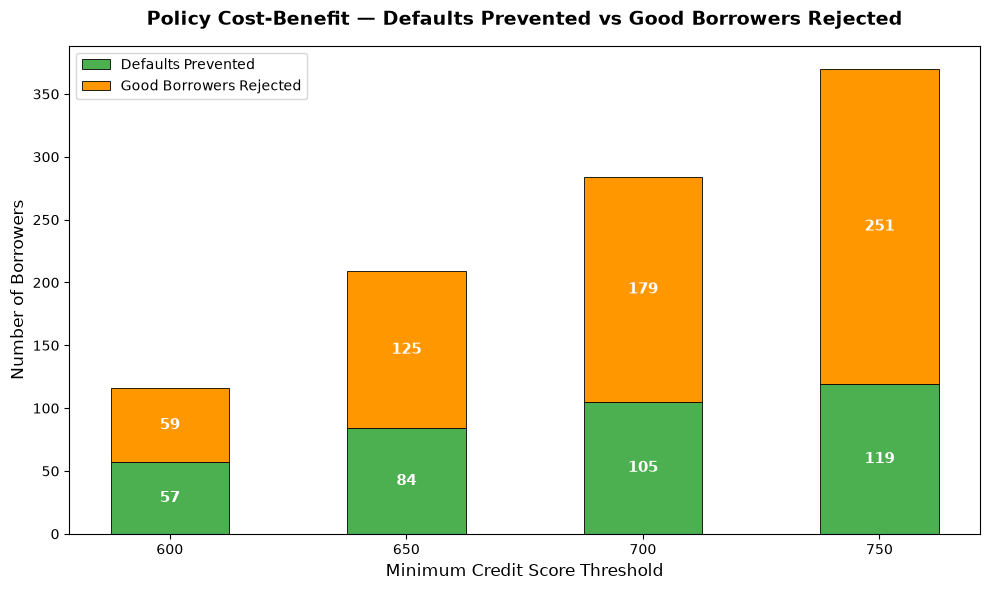


✅ Cost-benefit chart saved → reports/policy_cost_benefit.png


In [19]:
# ────────────────────────────────────────────────────────────────
# Stacked View — Defaults Prevented vs Good Borrowers Rejected
# ────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(thresholds))
width = 0.5

ax.bar(x, sim_df['Defaults Prevented'], width,
       label='Defaults Prevented', color='#4CAF50',
       edgecolor='black', linewidth=0.6)
ax.bar(x, sim_df['Good Borrowers Rejected'], width,
       bottom=sim_df['Defaults Prevented'],
       label='Good Borrowers Rejected', color='#FF9800',
       edgecolor='black', linewidth=0.6)

for i, (dp, gr) in enumerate(zip(sim_df['Defaults Prevented'],
                                  sim_df['Good Borrowers Rejected'])):
    ax.text(i, dp / 2, str(dp), ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(i, dp + gr / 2, str(gr), ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

ax.set_xlabel('Minimum Credit Score Threshold', fontsize=12)
ax.set_ylabel('Number of Borrowers', fontsize=12)
ax.set_title('Policy Cost-Benefit — Defaults Prevented vs Good Borrowers Rejected',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(thresholds_str)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/policy_cost_benefit.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Cost-benefit chart saved → reports/policy_cost_benefit.png")


📊  Extended Simulation Results
 Min Credit Score  Approval Rate (%)  Portfolio Default Rate (%)  Default Rate Reduction (pp)  Defaults Prevented  Good Borrowers Rejected  Net Benefit  Filter Efficiency (%)
              600              80.70                       18.35                         5.94                  57                       59           -2                  49.14
              650              65.22                       15.82                         8.47                  84                      125          -41                  40.19
              700              52.75                       12.93                        11.36                 105                      179          -74                  36.97
              750              38.44                       11.69                        12.60                 119                      251         -132                  32.16


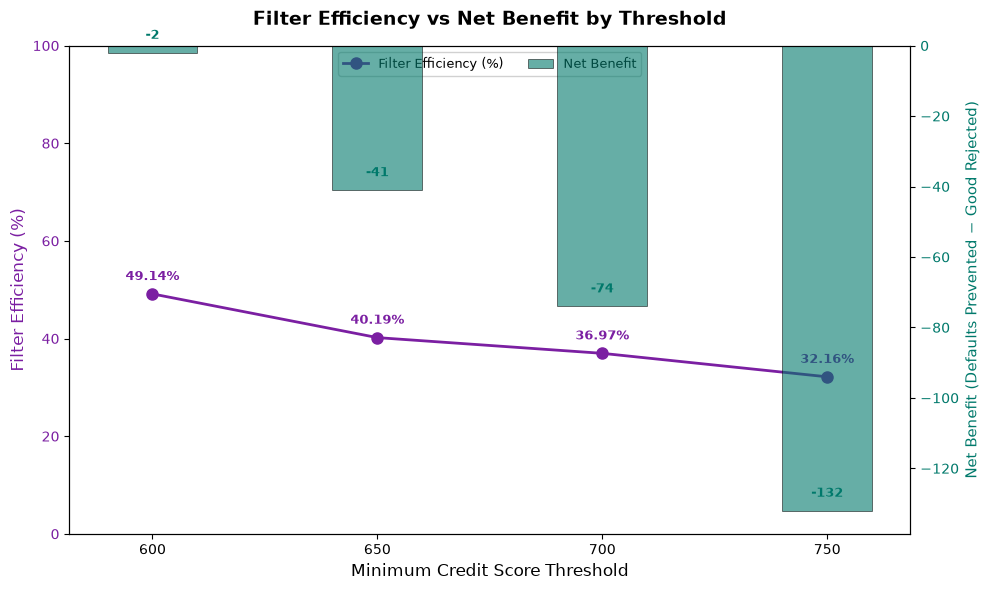


✅ Efficiency chart saved → reports/policy_efficiency.png


In [20]:
# ────────────────────────────────────────────────────────────────
# Net Benefit & Filtering Efficiency
# ────────────────────────────────────────────────────────────────

# Net Benefit = Defaults Prevented  −  Good Borrowers Rejected
# Efficiency  = Defaults Prevented  /  Total Rejected   (higher = more precise filter)

sim_df['Net Benefit'] = sim_df['Defaults Prevented'] - sim_df['Good Borrowers Rejected']
sim_df['Filter Efficiency (%)'] = round(
    sim_df['Defaults Prevented'] / (sim_df['Defaults Prevented'] + sim_df['Good Borrowers Rejected']) * 100, 2
)
sim_df['Default Rate Reduction (pp)'] = round(baseline_default_rate - sim_df['Portfolio Default Rate (%)'], 2)

print("📊  Extended Simulation Results")
print(sim_df[['Min Credit Score', 'Approval Rate (%)', 'Portfolio Default Rate (%)',
              'Default Rate Reduction (pp)', 'Defaults Prevented',
              'Good Borrowers Rejected', 'Net Benefit',
              'Filter Efficiency (%)']].to_string(index=False))

# ── Visualize efficiency vs net benefit ─────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))

color_eff = '#7B1FA2'
color_net = '#00796B'

ax1.plot(thresholds_str, sim_df['Filter Efficiency (%)'], 'o-',
         color=color_eff, linewidth=2, markersize=8, label='Filter Efficiency (%)')
ax1.set_xlabel('Minimum Credit Score Threshold', fontsize=12)
ax1.set_ylabel('Filter Efficiency (%)', fontsize=12, color=color_eff)
ax1.tick_params(axis='y', labelcolor=color_eff)
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
ax2.bar(thresholds_str, sim_df['Net Benefit'], 0.4,
        color=color_net, alpha=0.6, edgecolor='black',
        linewidth=0.6, label='Net Benefit')
ax2.set_ylabel('Net Benefit (Defaults Prevented − Good Rejected)',
               fontsize=11, color=color_net)
ax2.tick_params(axis='y', labelcolor=color_net)

# Annotate
for i, (eff, nb) in enumerate(zip(sim_df['Filter Efficiency (%)'],
                                   sim_df['Net Benefit'])):
    ax1.annotate(f'{eff}%', (i, eff), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9,
                 fontweight='bold', color=color_eff)
    ax2.annotate(str(nb), (i, nb), textcoords='offset points',
                 xytext=(0, -15 if nb >= 0 else 10), ha='center',
                 fontsize=9, fontweight='bold', color=color_net)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', fontsize=9, ncol=2, framealpha=0.9)

ax1.set_title('Filter Efficiency vs Net Benefit by Threshold',
              fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/policy_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Efficiency chart saved → reports/policy_efficiency.png")


---

### 🧠 Simulation Summary & Key Takeaways

This simulation transforms our analysis from **descriptive reporting** into a
**decision-support framework**. Instead of asking *"what happened?"*, risk teams can
now answer:

> **"What *would* happen to our loan portfolio if we changed our underwriting policy today?"**

#### Key Observations

1. **Lower thresholds (600)** maximize business volume (high approval rate) but leave
   the portfolio exposed to high default rates, well above the 12% company target.

2. **Higher thresholds (750)** dramatically reduce defaults but at the cost of
   rejecting a significant number of creditworthy borrowers — shrinking the business.

3. **Filter Efficiency** reveals how precise each threshold is: a high efficiency
   means most rejected applicants *would have* defaulted; a low efficiency means the
   policy is overly aggressive, turning away good customers.

4. **Net Benefit** (Defaults Prevented − Good Borrowers Rejected) quantifies whether
   a threshold creates more value than it destroys.

#### Recommendation Framework

| Priority | Recommended Threshold | Rationale |
|----------|----------------------|-----------|
| **Growth-first** | 600 – 650 | Maximize approvals; accept higher risk |
| **Balanced** | 650 – 700 | Moderate risk reduction with acceptable business volume |
| **Risk-first** | 700 – 750 | Aggressively cut defaults; accept reduced volume |

> **Note:** The optimal threshold depends on the organization's risk appetite,
> capital reserves, and growth targets. This simulation provides the data;
> management provides the strategy.


---

## 🏦 Credit Score Policy Simulation — Decision-Support Framework

> **Objective:** Evaluate different minimum credit score policies (600, 650, 700, 750)
> and quantify their impact on key portfolio metrics — helping management answer:
>
> *"What would happen to our loan portfolio if we changed our underwriting policy today?"*

Rather than simply recommending a single threshold, this simulation **quantifies the
business consequences** of each underwriting policy by measuring:

| Metric | Description |
|--------|-------------|
| **Approval Rate** | % of applicants that would be approved |
| **Portfolio Default Rate** | Default rate among approved loans |
| **Defaults Prevented** | How many defaults the policy would avoid |
| **Good Borrowers Rejected** | Non-defaulting applicants lost due to the higher bar |

This transforms the analysis from descriptive reporting into a **decision-support
framework** for risk teams and management.


In [21]:
import pandas as pd

# Load merged dataset
df = pd.read_csv('../data/merged_loan_data.csv')

# -------------------------------
# Baseline Portfolio Metrics
# -------------------------------
total_loans = len(df)
total_defaults = int(df['defaulted'].sum())
baseline_default_rate = round(total_defaults / total_loans * 100, 2)

# Credit score policies to evaluate
thresholds = [600, 650, 700, 750]

results = []

for threshold in thresholds:

    # Loans approved and rejected under the policy
    approved = df[df['credit_score'] >= threshold]
    rejected = df[df['credit_score'] < threshold]

    # Basic metrics
    approved_loans = len(approved)
    rejected_loans = len(rejected)

    approval_rate = round(
        approved_loans / total_loans * 100, 2
    )

    approved_defaults = int(approved['defaulted'].sum())
    rejected_defaults = int(rejected['defaulted'].sum())

    portfolio_default_rate = round(
        approved_defaults / approved_loans * 100, 2
    ) if approved_loans > 0 else 0

    defaults_prevented = rejected_defaults

    good_borrowers_rejected = (
        rejected_loans - rejected_defaults
    )

    # Total value of loans rejected
    rejected_loan_volume = rejected['loan_amount'].sum()

    # Estimated credit loss avoided
    # (Assumes every rejected default would have resulted in full loan loss)
    estimated_loss_avoided = rejected.loc[
        rejected['defaulted'] == 1,
        'loan_amount'
    ].sum()

    results.append({
        'Min Credit Score': threshold,
        'Approved Loans': approved_loans,
        'Rejected Loans': rejected_loans,
        'Approval Rate (%)': approval_rate,
        'Approved Defaults': approved_defaults,
        'Portfolio Default Rate (%)': portfolio_default_rate,
        'Defaults Prevented': defaults_prevented,
        'Good Borrowers Rejected': good_borrowers_rejected,
        'Rejected Loan Volume ($)': round(rejected_loan_volume, 2),
        'Estimated Loss Avoided ($)': round(estimated_loss_avoided, 2)
    })

# Create summary DataFrame
policy_simulation = pd.DataFrame(results)

# -------------------------------
# Print Results
# -------------------------------
print("=" * 70)
print("BASELINE PORTFOLIO")
print("=" * 70)

print(f"Total Loans        : {total_loans}")
print(f"Total Defaults     : {total_defaults}")
print(f"Default Rate       : {baseline_default_rate:.2f}%")
print(f"Company Target     : 12.00%")
print(f"Gap Above Target   : {baseline_default_rate - 12:.2f}%")

print("\n" + "=" * 70)
print("UNDERWRITING POLICY SCENARIO ANALYSIS")
print("=" * 70)

print(policy_simulation.to_string(index=False))
policy_simulation.to_csv(r'../data/policy_simulation.csv',index=False)

BASELINE PORTFOLIO
Total Loans        : 601
Total Defaults     : 146
Default Rate       : 24.29%
Company Target     : 12.00%
Gap Above Target   : 12.29%

UNDERWRITING POLICY SCENARIO ANALYSIS
 Min Credit Score  Approved Loans  Rejected Loans  Approval Rate (%)  Approved Defaults  Portfolio Default Rate (%)  Defaults Prevented  Good Borrowers Rejected  Rejected Loan Volume ($)  Estimated Loss Avoided ($)
              600             485             116              80.70                 89                       18.35                  57                       59                 2723900.0                   1376600.0
              650             392             209              65.22                 62                       15.82                  84                      125                 4509200.0                   1901000.0
              700             317             284              52.75                 41                       12.93                 105                      179   

### 📋 How to Read the Simulation Table

| Column | Interpretation |
|--------|---------------|
| **Min Credit Score** | The floor a borrower must meet to be approved |
| **Approved / Rejected** | Volume of loans passing or failing the gate |
| **Approval Rate (%)** | Business growth indicator — lower = fewer customers |
| **Portfolio Default Rate (%)** | Risk indicator — lower = safer portfolio |
| **Defaults Prevented** | Absolute risk reduction vs. baseline (no filter) |
| **Good Borrowers Rejected** | Opportunity cost — revenue lost from safe borrowers |


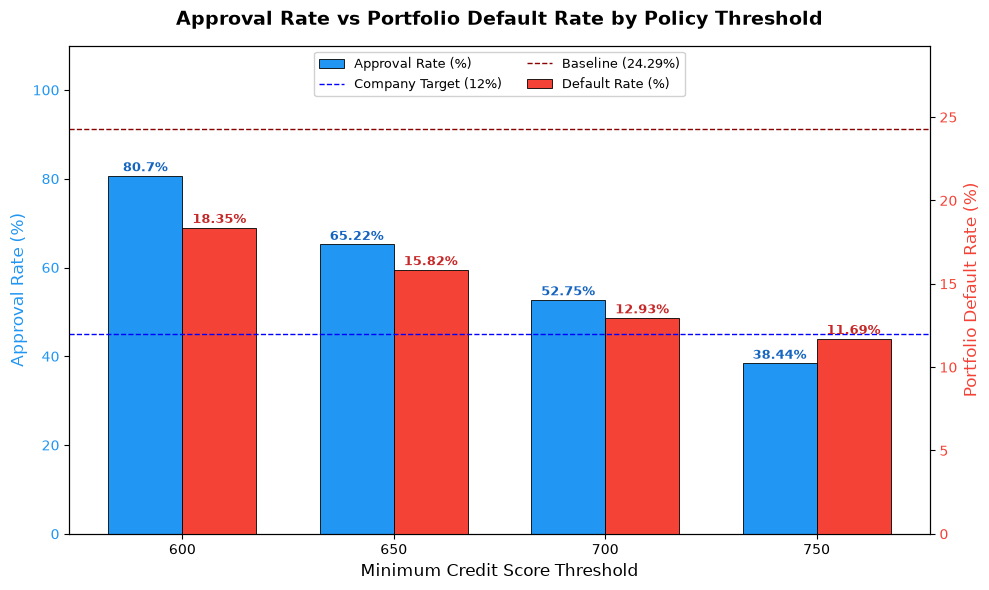


Overlay chart saved → reports/policy_tradeoff_overlay.png


In [22]:


fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(thresholds))
width = 0.35

# Left axis — Approval Rate
bars1 = ax1.bar(x - width/2, sim_df['Approval Rate (%)'], width,
                label='Approval Rate (%)', color='#2196F3',
                edgecolor='black', linewidth=0.6)
ax1.set_xlabel('Minimum Credit Score Threshold', fontsize=12)
ax1.set_ylabel('Approval Rate (%)', fontsize=12, color='#2196F3')
ax1.set_xticks(x)
ax1.set_xticklabels(thresholds_str)
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.set_ylim(0, 110)

# Right axis — Default Rate
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, sim_df['Portfolio Default Rate (%)'], width,
                label='Default Rate (%)', color='#F44336',
                edgecolor='black', linewidth=0.6)
ax2.set_ylabel('Portfolio Default Rate (%)', fontsize=12, color='#F44336')
ax2.tick_params(axis='y', labelcolor='#F44336')
ax2.set_ylim(0, max(sim_df['Portfolio Default Rate (%)'].max(), baseline_default_rate) + 5)

# Reference lines
ax2.axhline(12, color='blue', linestyle='--', linewidth=1,
            label='Company Target (12%)')
ax2.axhline(baseline_default_rate, color='darkred', linestyle='--',
            linewidth=1, label=f'Baseline ({baseline_default_rate}%)')

# Labels on bars
for bar, val in zip(bars1, sim_df['Approval Rate (%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}%', ha='center', fontsize=9, fontweight='bold', color='#1565C0')
for bar, val in zip(bars2, sim_df['Portfolio Default Rate (%)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=9, fontweight='bold', color='#C62828')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center',
           fontsize=9, ncol=2, framealpha=0.9)

ax1.set_title('Approval Rate vs Portfolio Default Rate by Policy Threshold',
              fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/policy_tradeoff_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nOverlay chart saved → reports/policy_tradeoff_overlay.png")
